# Get started with Time series 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [11]:
# header=0: first row is header
us_gdp = pd.read_csv("../data/GDPUS.csv", header=0)

# Use 'A' for broad pandas compatibility (year-end frequency).
date_range = pd.date_range(start='1/1/1929', end='31/12/1991', freq='A')

# Add TimeIndex column to the dataframe.
us_gdp['TimeIndex'] = pd.DataFrame(date_range, columns=['Year'])

us_gdp.head(5).T

/tmp/ipykernel_1689119/2469103103.py:5: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  date_range = pd.date_range(start='1/1/1929', end='31/12/1991', freq='A')


,0,1,2,3,4
Year,1929,1930,1931,1932,1933
GDP,821.8,748.9,691.3,599.7,587.1
TimeIndex,1929-12-31 00:00:00,1930-12-31 00:00:00,1931-12-31 00:00:00,1932-12-31 00:00:00,1933-12-31 00:00:00


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


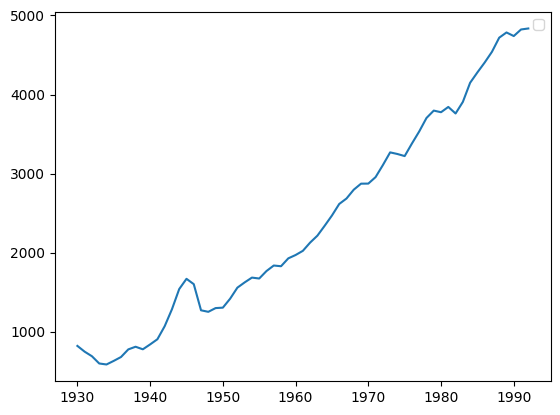

In [5]:
plt.plot(us_gdp.TimeIndex, us_gdp.GDP)
plt.legend(loc='best')
plt.show()

## Time series components: Seasonality

In [14]:
tractor_sales_data = pd.read_csv("../data/tractor_salesSales.csv")
tractor_sales_data.head(5)

,Month-Year,Number of Tractor Sold
0,3-Jan,141
1,3-Feb,157
2,3-Mar,185
3,3-Apr,199
4,3-May,203


In [ ]:
date_ser = pd.date_range(start='2003-01-01', freq='MS', periods=len(tractor_sales_data))

In [19]:
tractor_sales_data.rename(columns={'Number of Tractor Sold':'Tractor-Sales'}, inplace=True)
tractor_sales_data.set_index(date_ser, inplace=True)
tractor_sales_data = tractor_sales_data[['Tractor-Sales']]
tractor_sales_data.head(5)

,Tractor-Sales
2003-01-01,141
2003-02-01,157
2003-03-01,185
2003-04-01,199
2003-05-01,203


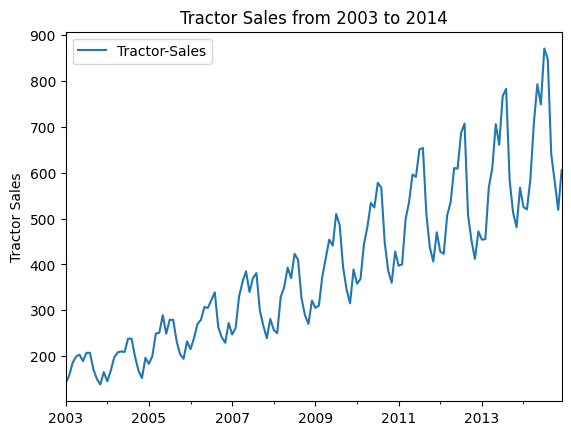

In [20]:
tractor_sales_data.plot()
plt.ylabel('Tractor Sales')
plt.title("Tractor Sales from 2003 to 2014")
plt.show()

## Plot by custom period (3M, 6M, 1Y)

In [21]:
def plot_by_period(df, value_col='Tractor-Sales', period='3M', agg='sum'):
    """Resample monthly time series and plot by period.

    period: int (months) or one of {'3M','6M','1Y','12M'}
    agg: one of {'sum','mean','max','min'}
    """
    if value_col not in df.columns:
        raise ValueError(f"Column '{value_col}' not found in dataframe.")

    if agg not in {'sum', 'mean', 'max', 'min'}:
        raise ValueError("agg must be one of: 'sum', 'mean', 'max', 'min'.")

    # Normalize period to pandas resample rule.
    if isinstance(period, int):
        if period <= 0:
            raise ValueError('period (months) must be > 0.')
        rule = f'{period}MS'
        period_label = f'{period}M'
    else:
        p = str(period).upper().strip()
        period_map = {
            '3M': '3MS',
            '6M': '6MS',
            '12M': '12MS',
            '1Y': 'YS',
            'Y': 'YS',
            'A': 'YS'
        }
        if p not in period_map:
            raise ValueError("period must be int months or one of: '3M', '6M', '12M', '1Y'.")
        rule = period_map[p]
        period_label = p

    series = df[value_col].resample(rule)
    result = getattr(series, agg)()

    plt.figure(figsize=(10, 4))
    plt.plot(result.index, result.values, marker='o')
    plt.ylabel(value_col)
    plt.title(f"{value_col} grouped by {period_label} ({agg})")
    plt.grid(alpha=0.25)
    plt.show()

    return result.to_frame(name=value_col)

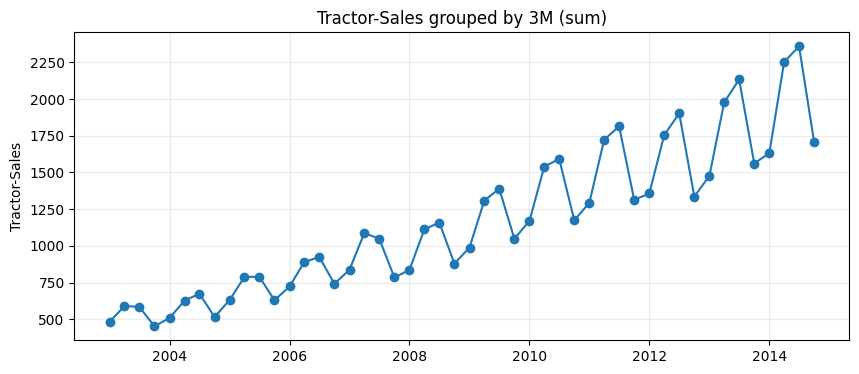

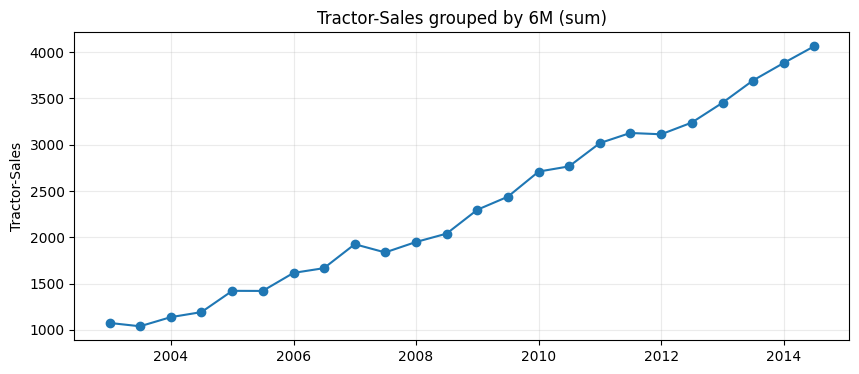

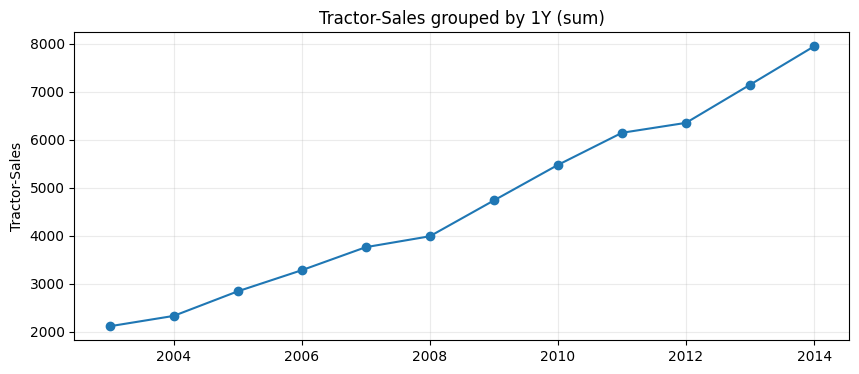

(            Tractor-Sales
 2003-01-01            483
 2003-04-01            591
 2003-07-01            585,
             Tractor-Sales
 2003-01-01           1074
 2003-07-01           1038
 2004-01-01           1137,
             Tractor-Sales
 2003-01-01           2112
 2004-01-01           2328
 2005-01-01           2841)

In [22]:
sales_3m = plot_by_period(tractor_sales_data, period='3M', agg='sum')
sales_6m = plot_by_period(tractor_sales_data, period='6M', agg='sum')
sales_1y = plot_by_period(tractor_sales_data, period='1Y', agg='sum')

sales_3m.head(3), sales_6m.head(3), sales_1y.head(3)

## Decomposition with Multiplicative model

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

In [25]:
turn_over_data = pd.read_csv('../data/RetailTurnover.csv')
date_range = pd.date_range(start='1/7/1982', end='31/3/1992',freq='Q')
turn_over_data['TimeIndex'] = pd.DataFrame(date_range,columns=['Quarter'])

/tmp/ipykernel_1689119/1696116609.py:2: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  date_range = pd.date_range(start='1/7/1982', end='31/3/1992',freq='Q')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


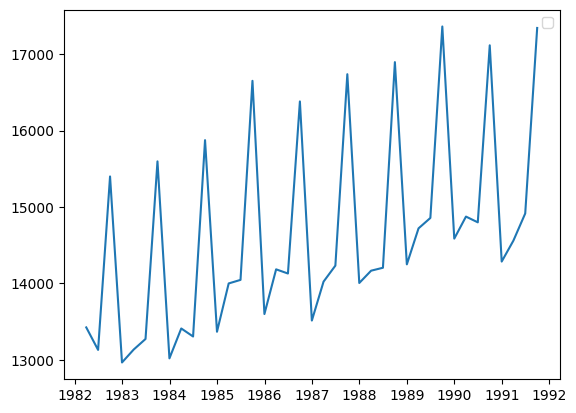

In [26]:
plt.plot(turn_over_data.TimeIndex, turn_over_data.Turnover)
plt.legend(loc='best')
plt.show()

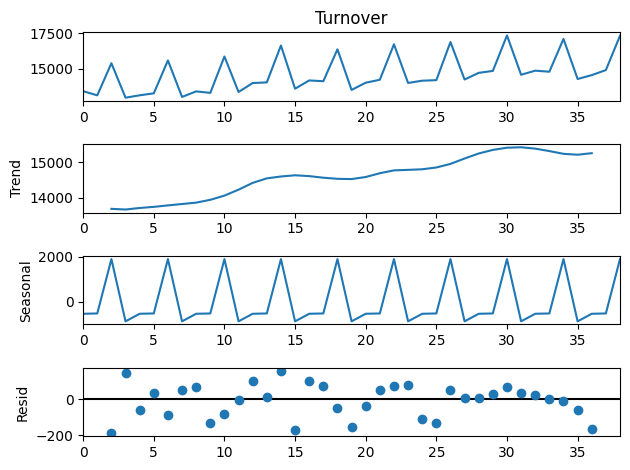

In [28]:
decomp_turn_over = sm.tsa.seasonal_decompose(turn_over_data.Turnover, model="additive", period=4)
decomp_turn_over.plot()
plt.show()